# 목표

번역기 만들기

In [1]:
import os

ROOT_DIR = os.getcwd()
DATA_DIR = os.path.join(ROOT_DIR, "data")

train_json_path = os.path.join(DATA_DIR, "raw", "일상생활및구어체_한영_train_set.json")
val_json_path = os.path.join(DATA_DIR, "raw", "일상생활및구어체_한영_valid_set.json")

In [2]:
import json

with open(train_json_path, "r", encoding="utf-8") as f:
    TRAIN_DATA = json.load(f)

TRAIN_DATA = TRAIN_DATA["data"]

In [3]:
import random

rand_idx = random.randint(1, len(TRAIN_DATA)) - 1

TRAIN_DATA[26]

{'sn': 'KPUS062012215029114',
 'data_set': '일상생활및구어체',
 'domain': '일상생활',
 'subdomain': '구매',
 'ko_original': '>와우영미.',
 'ko': '>와우영미.',
 'mt': '> Wow, Woo Youngmi.',
 'en': '> WaWooYoungmi.',
 'source_language': 'ko',
 'target_language': 'en',
 'word_count_ko': 1,
 'word_count_en': 2,
 'word_ratio': 2.0,
 'file_name': '구매_KPUS.xlsx',
 'source': 'SBS',
 'license': 'open',
 'style': '구어체',
 'included_unknown_words': False,
 'ner': {'text': '>와우<PERSON>영미</PERSON>.',
  'tags': [{'tag': 'PERSON', 'value': '영미', 'position': '[3, 5]'}]}}

ner은 Named Entity Recognition. 꼭 살려둬야 한다.

In [4]:
print("[데이터 속성 고유값]")

unique_dict = {key: (set() if key != "ner" else list()) for key in TRAIN_DATA[0].keys()}


for i, dict_ in enumerate(TRAIN_DATA):   
    for key, value in dict_.items():
        if key == "ner":
            unique_dict[key].append(value if value else "null")
        else:
            unique_dict[key].add(value if value else "null")


for key, value in unique_dict.items():
    print(f"· {key}: {len(value)}개")

    if len(value) < 20:
        print(f"    - {value}")

[데이터 속성 고유값]
· sn: 1200000개
· data_set: 1개
    - {'일상생활및구어체'}
· domain: 3개
    - {'해외고객과의채팅', '해외영업', '일상생활'}
· subdomain: 11개
    - {'부동산', '기계장비,의료정밀', '도소매유통', '구매', '여행', '예약', '정보통신', '금융,보험', '음식', '연구개발,과학기술', '숙박,음식점'}
· ko_original: 1059799개
· ko: 1059798개
· mt: 1015045개
· en: 1024329개
· source_language: 1개
    - {'ko'}
· target_language: 1개
    - {'en'}
· word_count_ko: 56개
· word_count_en: 73개
· word_ratio: 673개
· file_name: 18개
    - {'CUSCHA_DSUT.xlsx', 'CUSCHA_STRS.xlsx', 'INTSAL_DSUT.xlsx', '여행_KTOS.xlsx', 'INTSAL_FNIN.xlsx', 'CUSCHA_FNIN.xlsx', 'CUSCHA_MCHO.xlsx', 'CUSCHA_RLST.xlsx', '음식_KFDS.xlsx', 'CUSCHA_JBTS.xlsx', '예약_KRSS.xlsx', 'INTSAL_STRS.xlsx', 'INTSAL_JBTS.xlsx', 'CUSCHA_EGKG.xlsx', '구매_KPUS.xlsx', 'INTSAL_RLST.xlsx', 'INTSAL_MCHO.xlsx', 'INTSAL_EGKG.xlsx'}
· source: 2개
    - {'SBS', '크라우드소싱'}
· license: 1개
    - {'open'}
· style: 1개
    - {'구어체'}
· included_unknown_words: 1개
    - {'null'}
· ner: 1200000개


In [5]:
import pandas as pd

useless_list = [
    "sn", "data_set", "license", "source", "style", 
    "included_unknown_words", "file_name", 
    "source_language", "target_language"
    ]

useful_list = [column for column in list(TRAIN_DATA[0].keys()) if column not in useless_list]

train_df = pd.DataFrame(TRAIN_DATA, columns=useful_list)

내용 중복 삭제

: domain, subdomain, 내용이 일치하는 데이터를 언어별로 삭제.

In [6]:
lang_list = [["ko_original", "en"], ["ko", "mt"]]

for lang in lang_list:
    train_df = train_df.drop_duplicates(["domain", "subdomain"] + lang, keep="first")

print(f"· 중복 제거 후 데이터: {len(train_df)}개")

· 중복 제거 후 데이터: 1080887개


In [7]:
# 도메인 맵핑
domain_map = {value: i for i, value in enumerate(unique_dict["domain"])}
subdomain_map = {value: i for i, value in enumerate(unique_dict["subdomain"])}

train_df["domain"] = train_df['domain'].map(domain_map)
train_df["subdomain"] = train_df['subdomain'].map(subdomain_map)

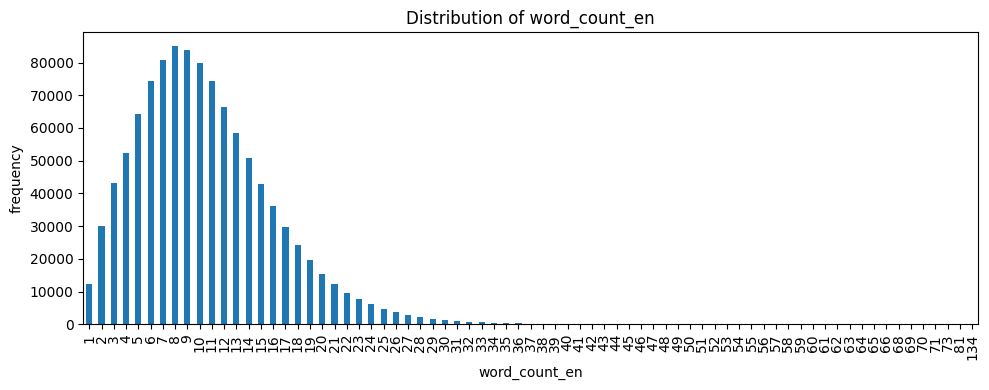

In [8]:
import matplotlib.pyplot as plt

counts = train_df["word_count_en"].value_counts().sort_index()

plt.figure(figsize=(10,4))
counts.plot(kind="bar")
plt.xlabel("word_count_en")
plt.ylabel("frequency")
plt.title("Distribution of word_count_en")
plt.tight_layout()
plt.show()

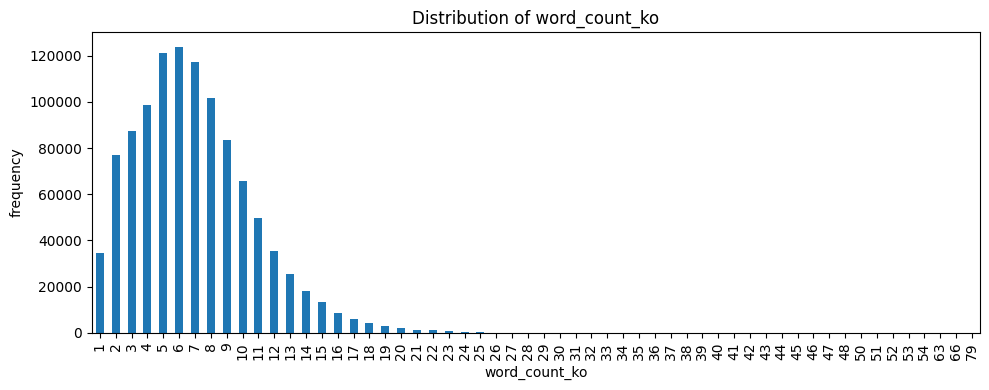

In [9]:
counts = train_df["word_count_ko"].value_counts().sort_index()

plt.figure(figsize=(10,4))
counts.plot(kind="bar")
plt.xlabel("word_count_ko")
plt.ylabel("frequency")
plt.title("Distribution of word_count_ko")
plt.tight_layout()
plt.show()

In [ ]:
TRAIN_DATA = train_df.to_dict("index")

KeyboardInterrupt: 

Exception ignored in: 'zmq.backend.cython._zmq.Frame.__dealloc__'
Traceback (most recent call last):
  File "zmq/backend/cython/_zmq.py", line 179, in zmq.backend.cython._zmq._check_rc
KeyboardInterrupt: 


In [ ]:
rand_idx = random.randint(1, len(TRAIN_DATA)) - 1

print("[가공 후 샘플 출력]")
print(f"key: {rand_idx}")
TRAIN_DATA[rand_idx]

[가공 후 샘플 출력]
key: 14617


{'domain': 2,
 'subdomain': 8,
 'ko_original': '파우치에는 4캔까지도 수납이 가능한 넉넉한 크기로 쿨러가 내장되어 있어 일어날 필요 없이 손만 뻗으면 시원한 음료를 즐길 수 있습니다.',
 'ko': '파우치에는 4캔까지도 수납이 가능한 넉넉한 크기로 쿨러가 내장되어 있어 일어날 필요 없이 손만 뻗으면 시원한 음료를 즐길 수 있습니다.',
 'mt': 'The pouch is large enough to hold up to 4 cans and has a built-in cooler.',
 'en': 'The pouch is large enough to hold up to 4 cans and has a built-in cooler.',
 'word_count_ko': 19,
 'word_count_en': 16,
 'word_ratio': 0.842,
 'ner': None}